In [ ]:
import pandas as pd
import glob
from openpyxl import load_workbook

excel_file = "/content/drive/Shareddrives/DU lab/Matteo Riva/WebApp/dati_sintetici.xlsx"

df = pd.read_excel("/content/drive/Shareddrives/DU lab/Matteo Riva/WebApp/dati_sintetici.xlsx", sheet_name="Fumo")

df["Data"] = pd.to_datetime(df["Data"], errors='coerce')
df = df.sort_values(by="Data")

columns_to_drop = ['Tempo']

df = df.drop(columns=[col for col in columns_to_drop if col in df.columns])

df_sum = df.groupby(['Utente', 'Data', 'Fumo'])['Quantità'].sum().reset_index()

df_unique = df_sum.drop_duplicates()

df_pivot = df_unique.pivot_table(index=['Utente', 'Data'], columns='Fumo', values='Quantità', fill_value=0).reset_index()

book = load_workbook(excel_file)

if "Fumo" in book.sheetnames:
    del book["Fumo"]
    book.save(excel_file)

with pd.ExcelWriter(excel_file, engine="openpyxl", mode="a", if_sheet_exists="replace") as writer:
    df_pivot.to_excel(writer, sheet_name="Fumo", index=False)

print("Foglio di lavoro 'Fumo' sovrascritto con i nuovi dati.")

Foglio di lavoro 'Fumo' sovrascritto con i nuovi dati.


In [ ]:
import pandas as pd
import glob
from openpyxl import load_workbook

excel_file = "/content/drive/Shareddrives/DU lab/Matteo Riva/WebApp/dati_sintetici.xlsx"

df = pd.read_excel("/content/drive/Shareddrives/DU lab/Matteo Riva/WebApp/dati_sintetici.xlsx", sheet_name="Dieta")

df["Data"] = pd.to_datetime(df["Data"], errors='coerce')
df = df.sort_values(by="Data")

df = df.assign(Cibo=df['Cibo'].str.split('\n')).explode('Cibo').reset_index(drop=True)

df['Cibo'] = df['Ora'] + ' ' + df['Cibo']

columns_to_drop = ['Tempo', 'Ora']

df = df.drop(columns=[col for col in columns_to_drop if col in df.columns])

df['n'] = 1

df_unique = df.drop_duplicates()

df_pivot = df_unique.pivot_table(index=['Utente', 'Data'], columns='Cibo', values='n', fill_value=0).reset_index()

book = load_workbook(excel_file)

if "Dieta" in book.sheetnames:
    del book["Dieta"]
    book.save(excel_file)

with pd.ExcelWriter(excel_file, engine="openpyxl", mode="a", if_sheet_exists="replace") as writer:
    df_pivot.to_excel(writer, sheet_name="Dieta", index=False)

print("Foglio di lavoro 'Dieta' sovrascritto con i nuovi dati.")

Foglio di lavoro 'Dieta' sovrascritto con i nuovi dati.


In [ ]:
import pandas as pd
import glob
from openpyxl import load_workbook

excel_file = "/content/drive/Shareddrives/DU lab/Matteo Riva/WebApp/dati_sintetici.xlsx"

df = pd.read_excel("/content/drive/Shareddrives/DU lab/Matteo Riva/WebApp/dati_sintetici.xlsx", sheet_name="Attività")

df["Data"] = pd.to_datetime(df["Data"], errors='coerce')
df = df.sort_values(by="Data")

columns_to_drop = ['Tempo', 'Durata']

df = df.drop(columns=[col for col in columns_to_drop if col in df.columns])

df['n'] = 1

df_unique = df.drop_duplicates()

df_pivot = df_unique.pivot_table(index=['Utente', 'Data'], columns='Tipologia', values='n', fill_value=0).reset_index()

book = load_workbook(excel_file)

if "Attività" in book.sheetnames:
    del book["Attività"]
    book.save(excel_file)

with pd.ExcelWriter(excel_file, engine="openpyxl", mode="a", if_sheet_exists="replace") as writer:
    df_pivot.to_excel(writer, sheet_name="Attività", index=False)

print("Foglio di lavoro 'Attività' sovrascritto con i nuovi dati.")

Foglio di lavoro 'Attività' sovrascritto con i nuovi dati.


In [ ]:
import pandas as pd
import glob
from openpyxl import load_workbook

excel_file = "/content/drive/Shareddrives/DU lab/Matteo Riva/WebApp/dati_sintetici.xlsx"

df = pd.read_excel(excel_file, sheet_name="Farmaci")

df["Data"] = pd.to_datetime(df["Data"], errors='coerce')
df = df.sort_values(by="Data")

columns_to_drop = ['Tempo', 'Motivazione', 'Specifica altra terapia']
df = df.drop(columns=[col for col in columns_to_drop if col in df.columns])

df['n'] = 1

df_unique = df.drop_duplicates()

pivot_cronica = df_unique.pivot_table(index=['Utente', 'Data'], columns='Terapia cronica', values='n', fill_value=0)
pivot_occasionale = df_unique.pivot_table(index=['Utente', 'Data'], columns='Terapia occasionale', values='n', fill_value=0)
pivot_integratori = df_unique.pivot_table(index=['Utente', 'Data'], columns='Integratori', values='n', fill_value=0)

df_pivot = pd.concat([pivot_cronica, pivot_occasionale, pivot_integratori], axis=1).reset_index()

df_pivot.columns = df_pivot.columns.get_level_values(0)

book = load_workbook(excel_file)

if "Farmaci" in book.sheetnames:
    del book["Farmaci"]
    book.save(excel_file)

with pd.ExcelWriter(excel_file, engine="openpyxl", mode="a", if_sheet_exists="replace") as writer:
    df_pivot.to_excel(writer, sheet_name="Farmaci", index=False)

print("Foglio di lavoro 'Farmaci' sovrascritto con i nuovi dati.")


Foglio di lavoro 'Farmaci' sovrascritto con i nuovi dati.


In [ ]:
import pandas as pd
import glob
from openpyxl import load_workbook

excel_file = "/content/drive/Shareddrives/DU lab/Matteo Riva/WebApp/dati_sintetici.xlsx"

df = pd.read_excel(excel_file, sheet_name="Sintomi")

df.rename(columns={"Paramentri sangue": "Parametri sangue"}, inplace=True)

# Convertire "Dolore addominale" e "Urgenza" in numerico
df["Dolore addominale"] = df["Dolore addominale"].map({"Si": 1, "No": 0})
df["Urgenza"] = df["Urgenza"].map({"Si": 1, "No": 0})

df["Data"] = pd.to_datetime(df["Data"], errors='coerce')

df_dolore_urgenza = df.groupby(['Utente', 'Data'])[['Dolore addominale', 'Urgenza']].sum().reset_index()
df_dolore_urgenza["Data"] = pd.to_datetime(df_dolore_urgenza["Data"], errors='coerce')
df = df.sort_values(by="Data")

columns_to_drop = ['Tempo', 'Descrizione sintomo', 'Orario']
df = df.drop(columns=[col for col in columns_to_drop if col in df.columns])

df = df.groupby(['Utente', 'Data', 'Parametri sangue'])['Num. evacuazione'].sum().reset_index()

df_unique = df.drop_duplicates()

df_pivot = df.pivot_table(index=['Utente', 'Data'],
                          columns='Parametri sangue',
                          values='Num. evacuazione',
                          fill_value=0).reset_index()

df_pivot = df_pivot.merge(df_dolore_urgenza, on=['Utente', 'Data'], how='left')

df_pivot.columns = df_pivot.columns.get_level_values(0)

book = load_workbook(excel_file)

if "Sintomi" in book.sheetnames:
    del book["Sintomi"]
    book.save(excel_file)

with pd.ExcelWriter(excel_file, engine="openpyxl", mode="a", if_sheet_exists="replace") as writer:
    df_pivot.to_excel(writer, sheet_name="Sintomi", index=False)

print("Foglio di lavoro 'Sintomi' sovrascritto con i nuovi dati.")


Foglio di lavoro 'Sintomi' sovrascritto con i nuovi dati.


In [ ]:
import pandas as pd

# Carica tutti i fogli di lavoro dal file Excel
excel_file = '/content/drive/Shareddrives/DU lab/Matteo Riva/WebApp/dati_sintetici.xlsx'
sheets = pd.read_excel(excel_file, sheet_name=None, engine='openpyxl')

# Inizializza un DataFrame vuoto per memorizzare i dati combinati
combined_df = pd.DataFrame()

# Itera attraverso ogni foglio di lavoro e aggiungi i dati al DataFrame combinato
for sheet_name, df in sheets.items():
    combined_df = pd.concat([combined_df, df])

# Raggruppa i dati per la colonna 'Data' e aggrega i dati
grouped_df = combined_df.groupby(['Utente', 'Data']).sum().reset_index()

# Salva i dati raggruppati in un nuovo file Excel
grouped_df.to_excel('/content/drive/Shareddrives/DU lab/Matteo Riva/WebApp/dati_combinati.xlsx', index=False)

print("I dati sono stati combinati e salvati con successo in 'dati_combinati.xlsx'.")

I dati sono stati combinati e salvati con successo in 'dati_combinati.xlsx'.


/usr/local/lib/python3.11/dist-packages/pytorch_forecasting/data/timeseries.py:1301: UserWarning: Min encoder length and/or min_prediction_idx and/or min prediction length and/or lags are too large for 23 series/groups which therefore are not present in the dataset index. This means no predictions can be made for those series. First 10 removed groups: [{'__group_id__patient_id': '21'}, {'__group_id__patient_id': '30'}, {'__group_id__patient_id': '33'}, {'__group_id__patient_id': '36'}, {'__group_id__patient_id': '39'}, {'__group_id__patient_id': '42'}, {'__group_id__patient_id': '52'}, {'__group_id__patient_id': '54'}, {'__group_id__patient_id': '56'}, {'__group_id__patient_id': '6'}]
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pytorch_forecasting/data/encoders.py:315: UserWarning: Found 10 unknown classes which were set to NaN
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pytorch_forecasting/data/timeseries.py:1301: UserWarning: Min encoder length and/or min_pr

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/lightning/pytorch/loops/fit_loop.py:310: The number of training batches (5) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=30` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=30` reached.
INFO: GPU available: False, used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs


Correlation between the binary variable and variable_4 in the predictions: -0.059816261464587836


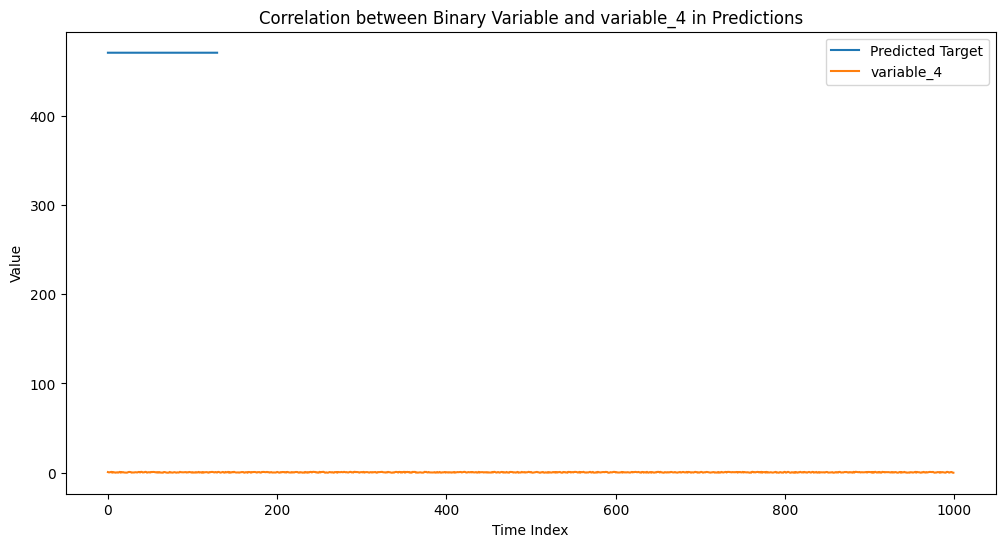

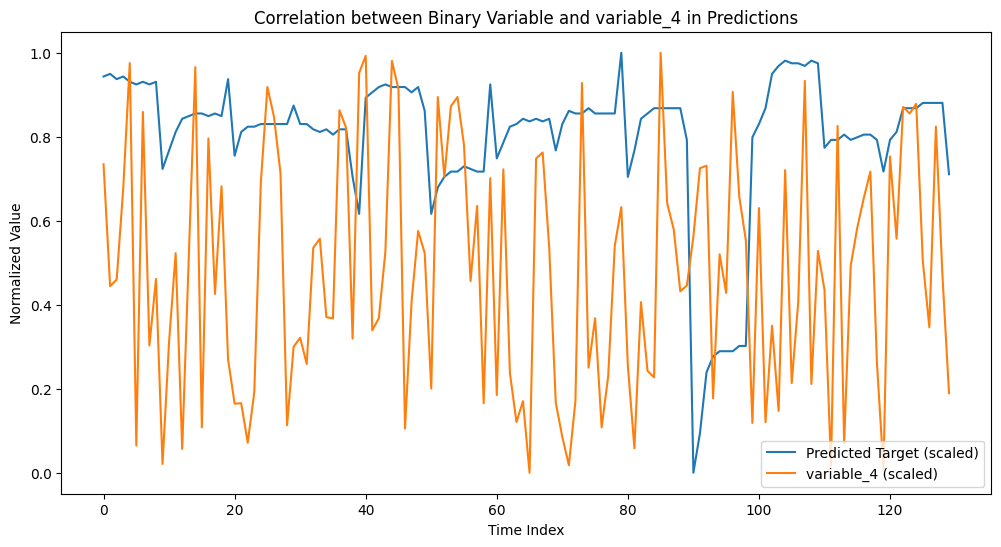

In [ ]:
# BING

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer, Baseline
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.data.encoders import NaNLabelEncoder
from pytorch_forecasting.metrics import SMAPE, QuantileLoss
# from lightning.pytorch import Trainer
import lightning.pytorch as pl
import torch

# Genera dati clinici casuali
np.random.seed(42)
data_size = 1000
data = {
    "time_idx": np.arange(data_size),
    "patient_id": np.random.randint(0, 100, data_size).astype(str),  # Converti patient_id in tipo stringa
    "variable_1": np.random.rand(data_size),
    "variable_2": np.random.rand(data_size),
    "variable_3": np.random.randint(0, 2, data_size),  # Variabile binaria (0 e 1)
    "variable_4": np.random.rand(data_size),
    "variable_5": np.random.rand(data_size),
    "target": np.random.rand(data_size)
}

df = pd.DataFrame(data)

# Definisci il dataset
max_encoder_length = 30
max_prediction_length = 10

training_cutoff = df["time_idx"].max() - max_prediction_length
training = TimeSeriesDataSet(
    df[df.time_idx <= training_cutoff],
    time_idx="time_idx",
    target="target",
    group_ids=["patient_id"],
    min_encoder_length=max_encoder_length // 2,
    max_encoder_length=max_encoder_length,
    min_prediction_length=1,
    max_prediction_length=max_prediction_length,
    static_categoricals=["patient_id"],
    time_varying_known_reals=["time_idx", "variable_1", "variable_2", "variable_3", "variable_4", "variable_5"],
    time_varying_unknown_reals=["target"],
    target_normalizer=NaNLabelEncoder(add_nan=True),
    allow_missing_timesteps=True,
)

validation = TimeSeriesDataSet.from_dataset(training, df, predict=True, stop_randomization=True)

# Crea dataloader per training e validation
batch_size = 64
train_dataloader = training.to_dataloader(train=True, batch_size=batch_size, num_workers=0)
val_dataloader = validation.to_dataloader(train=False, batch_size=batch_size, num_workers=0)

# Definisci il modello
pl.seed_everything(42)
trainer = pl.Trainer(
    max_epochs=30,
    gradient_clip_val=0.1,
)

tft = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate=0.03,
    hidden_size=16,
    attention_head_size=1,
    dropout=0.1,
    hidden_continuous_size=8,
    output_size=1,  # Single output dimension
    loss=SMAPE(),
)

# Allena il modello
trainer.fit(
    tft,
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader,
)

# Fai predizioni per i prossimi 14 giorni (2 settimane)
predictions = tft.predict(val_dataloader, mode="prediction")

# Seleziona la variabile binaria e una variabile casuale per l'analisi della correlazione
binary_variable = df["variable_3"]
random_variable_name = "variable_" + str(np.random.randint(1, 6))
random_variable = df[random_variable_name]

# Allinea le lunghezze delle serie
min_length = min(len(predictions.flatten()), len(random_variable))

# Seleziona solo i primi 'min_length' valori
predictions_aligned = predictions.flatten()[:min_length]
random_variable_aligned = random_variable[:min_length]

# Calcola la correlazione
correlation = np.corrcoef(predictions_aligned, random_variable_aligned)[0, 1]

print(f"Correlation between the binary variable and {random_variable_name} in the predictions: {correlation}")

# Crea il grafico dei risultati
plt.figure(figsize=(12, 6))
plt.plot(predictions.flatten(), label='Predicted Target')
plt.plot(random_variable, label=random_variable_name)
plt.xlabel('Time Index')
plt.ylabel('Value')
plt.title(f'Correlation between Binary Variable and {random_variable_name} in Predictions')
plt.legend()
plt.show()

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
predictions_scaled = scaler.fit_transform(predictions_aligned.reshape(-1, 1)).flatten()
random_variable_scaled = scaler.fit_transform(random_variable_aligned.values.reshape(-1, 1)).flatten()

plt.figure(figsize=(12, 6))
plt.plot(predictions_scaled, label='Predicted Target (scaled)')
plt.plot(random_variable_scaled, label=f'{random_variable_name} (scaled)')
plt.xlabel('Time Index')
plt.ylabel('Normalized Value')
plt.title(f'Correlation between Binary Variable and {random_variable_name} in Predictions')
plt.legend()
plt.show()


/usr/local/lib/python3.11/dist-packages/pytorch_forecasting/data/timeseries.py:1301: UserWarning: Min encoder length and/or min_prediction_idx and/or min prediction length and/or lags are too large for 21 series/groups which therefore are not present in the dataset index. This means no predictions can be made for those series. First 10 removed groups: [{'__group_id__patient_id': '21'}, {'__group_id__patient_id': '30'}, {'__group_id__patient_id': '36'}, {'__group_id__patient_id': '39'}, {'__group_id__patient_id': '42'}, {'__group_id__patient_id': '54'}, {'__group_id__patient_id': '56'}, {'__group_id__patient_id': '6'}, {'__group_id__patient_id': '66'}, {'__group_id__patient_id': '67'}]
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pytorch_forecasting/data/encoders.py:315: UserWarning: Found 14 unknown classes which were set to NaN
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pytorch_forecasting/data/timeseries.py:1301: UserWarning: Min encoder length and/or min_pr

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/lightning/pytorch/loops/fit_loop.py:310: The number of training batches (6) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=30` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=30` reached.
INFO: GPU available: False, used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs


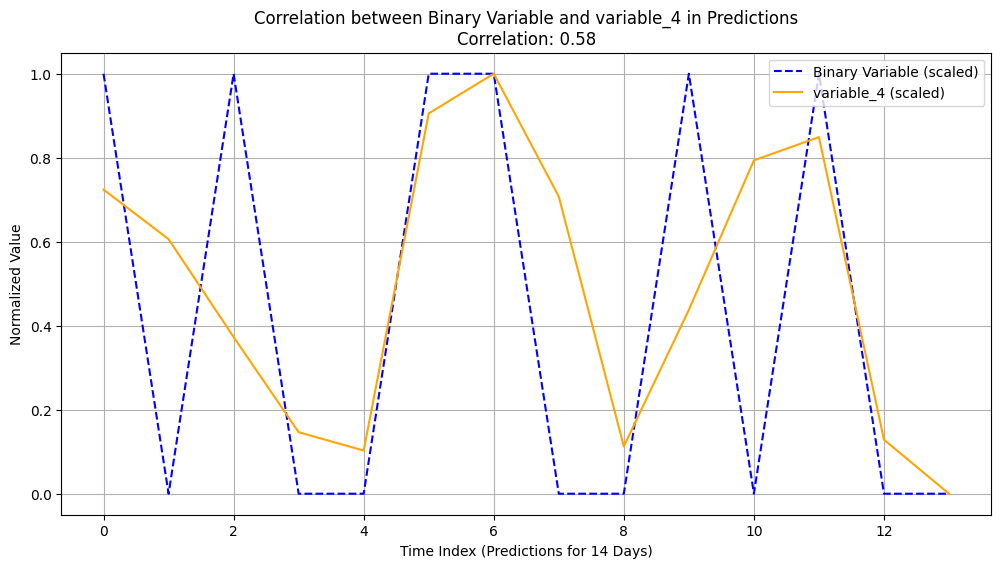

In [ ]:
# Importa librerie necessarie
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.data.encoders import NaNLabelEncoder
from pytorch_forecasting.metrics import SMAPE
import lightning.pytorch as pl
import torch

# Genera dati clinici casuali
np.random.seed(42)
data_size = 1000
data = {
    "time_idx": np.arange(data_size),
    "patient_id": np.random.randint(0, 100, data_size).astype(str),  # Converti patient_id in tipo stringa
    "variable_1": np.random.rand(data_size),
    "variable_2": np.random.rand(data_size),
    "variable_3": np.random.randint(0, 2, data_size),  # Variabile binaria (0 e 1)
    "variable_4": np.random.rand(data_size),
    "variable_5": np.random.rand(data_size),
    "target": np.random.rand(data_size)
}

df = pd.DataFrame(data)

# Definisci il dataset
max_encoder_length = 30
max_prediction_length = 14  # Prevediamo per 14 giorni

training_cutoff = df["time_idx"].max() - max_prediction_length
training = TimeSeriesDataSet(
    df[df.time_idx <= training_cutoff],
    time_idx="time_idx",
    target="target",
    group_ids=["patient_id"],
    min_encoder_length=max_encoder_length // 2,
    max_encoder_length=max_encoder_length,
    min_prediction_length=1,
    max_prediction_length=max_prediction_length,
    static_categoricals=["patient_id"],
    time_varying_known_reals=["time_idx", "variable_1", "variable_2", "variable_3", "variable_4", "variable_5"],
    time_varying_unknown_reals=["target"],
    target_normalizer=NaNLabelEncoder(add_nan=True),
    allow_missing_timesteps=True,
)

validation = TimeSeriesDataSet.from_dataset(training, df, predict=True, stop_randomization=True)

# Crea dataloader per training e validation
batch_size = 64
train_dataloader = training.to_dataloader(train=True, batch_size=batch_size, num_workers=0)
val_dataloader = validation.to_dataloader(train=False, batch_size=batch_size, num_workers=0)

# Definisci il modello
pl.seed_everything(42)
trainer = pl.Trainer(
    max_epochs=30,
    gradient_clip_val=0.1,
)

tft = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate=0.03,
    hidden_size=16,
    attention_head_size=1,
    dropout=0.1,
    hidden_continuous_size=8,
    output_size=1,  # Single output dimension
    loss=SMAPE(),
)

# Allena il modello
trainer.fit(
    tft,
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader,
)

# Fai predizioni per i prossimi 14 giorni (2 settimane)
predictions = tft.predict(val_dataloader, mode="prediction")

# Seleziona la variabile binaria e una variabile casuale per l'analisi della correlazione
binary_variable = df[df.time_idx > training_cutoff]["variable_3"][:max_prediction_length]  # Allineata alle predizioni
random_variable_name = "variable_" + str(np.random.randint(1, 6))
random_variable = df[df.time_idx > training_cutoff][random_variable_name][:max_prediction_length]  # Allineata

# Normalizza i dati per una migliore visualizzazione
scaler = MinMaxScaler()
predictions_scaled = scaler.fit_transform(predictions.reshape(-1, 1)).flatten()
binary_variable_scaled = scaler.fit_transform(binary_variable.values.reshape(-1, 1)).flatten()
random_variable_scaled = scaler.fit_transform(random_variable.values.reshape(-1, 1)).flatten()

# Calcola la correlazione tra la variabile binaria e la variabile casuale nelle predizioni
correlation = np.corrcoef(binary_variable_scaled, random_variable_scaled)[0, 1]

# Crea il grafico dei risultati
plt.figure(figsize=(12, 6))
plt.plot(range(len(binary_variable_scaled)), binary_variable_scaled, linestyle='dashed', color='blue', label='Binary Variable (scaled)')
plt.plot(range(len(random_variable_scaled)), random_variable_scaled, color='orange', label=f'{random_variable_name} (scaled)')
plt.xlabel('Time Index (Predictions for 14 Days)')
plt.ylabel('Normalized Value')
plt.title(f'Correlation between Binary Variable and {random_variable_name} in Predictions\nCorrelation: {correlation:.2f}')
plt.legend()
plt.grid()
plt.show()


In [ ]:
import pandas as pd

df = pd.read_csv("/content/drive/Shareddrives/DU lab/Matteo Riva/WebApp/dati_luca/raw_data/raw_data/colas.csv")
df = df[df['id'] == 1]
df.to_excel("/content/drive/Shareddrives/DU lab/Matteo Riva/WebApp/dati_luca_1.xlsx")

INFO:pytorch_lightning.utilities.rank_zero:You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
/usr/local/lib/python3.11/dist-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/usr/local/lib/python3.11/dist-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVI

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/lightning/pytorch/loops/fit_loop.py:310: The number of training batches (43) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

INFO: Monitored metric val_loss did not improve in the last 5 records. Best score: 15.422. Signaling Trainer to stop.
INFO:lightning.pytorch.callbacks.early_stopping:Monitored metric val_loss did not improve in the last 5 records. Best score: 15.422. Signaling Trainer to stop.


lightning_logs/lightning_logs/version_15/checkpoints/epoch=15-step=688.ckpt


/usr/local/lib/python3.11/dist-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/usr/local/lib/python3.11/dist-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


('output', 'x', 'index', 'decoder_lengths', 'y')
torch.Size([1, 10, 7])


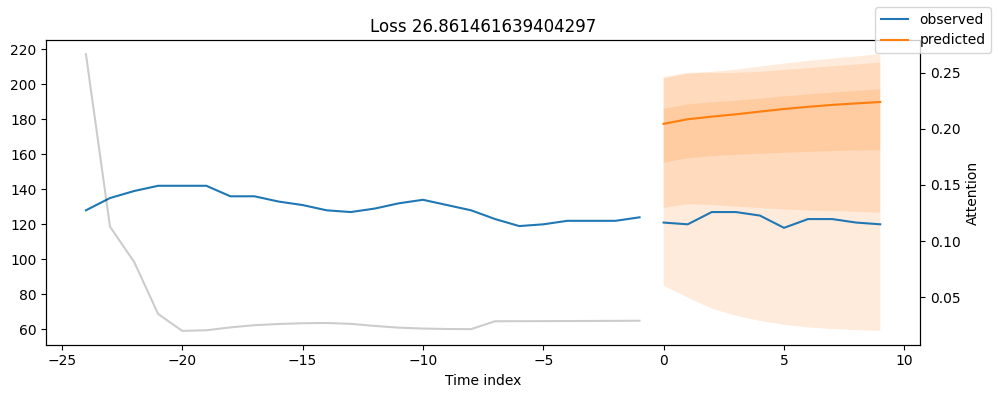

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import matplotlib.pyplot as plt
from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.metrics import QuantileLoss
from pytorch_lightning.loggers import TensorBoardLogger
from lightning.pytorch import Trainer

import lightning.pytorch as pl # Instead of import pytorch_lightning as pl
from lightning.pytorch.callbacks.early_stopping import EarlyStopping
from lightning.pytorch.callbacks import LearningRateMonitor

# Caricamento dati
df = pd.read_excel("/content/drive/Shareddrives/DU lab/Matteo Riva/WebApp/dati_luca_199.xlsx")
df["time"] = df.index  # Assumendo che i dati siano ordinati temporalmente

target = "gl"  # Nome della colonna target
group_ids = ["id"]  # Identificatore del gruppo (es. ID cliente, serie temporale)
df = df[df['id'] == 199]


max_encoder_length = 24
max_prediction_length = 10
batch_size = 64

training_cutoff = df["time"].max() - max_prediction_length
training = TimeSeriesDataSet(
    df[df.time <= training_cutoff],
    time_idx="time",
    target=target,
    group_ids=group_ids,
    time_varying_known_reals=["time"],
    time_varying_unknown_reals=[target],
    target_normalizer=GroupNormalizer(groups=group_ids),
    max_encoder_length=max_encoder_length,
    max_prediction_length=max_prediction_length,
)

validation = TimeSeriesDataSet.from_dataset(training, df, predict=True, stop_randomization=True)
train_dataloader = training.to_dataloader(train=True, batch_size=batch_size, num_workers=0)
val_dataloader = validation.to_dataloader(train=False, batch_size=batch_size, num_workers=0)

early_stop_callback = EarlyStopping(monitor="val_loss", min_delta=1e-4, patience=5, verbose=True, mode="min")
lr_logger = LearningRateMonitor()
logger = TensorBoardLogger("lightning_logs")

trainer = pl.Trainer(
    max_epochs=45,
    # accelerator='gpu',
    # devices=1,
    enable_model_summary=True,
    gradient_clip_val=0.1,
    callbacks=[lr_logger, early_stop_callback],
    logger=logger)

tft = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate=0.001,
    hidden_size=160,
    attention_head_size=4,
    dropout=0.1,
    hidden_continuous_size=160,
    output_size=7,  # there are 7 quantiles by default: [0.02, 0.1, 0.25, 0.5, 0.75, 0.9, 0.98]
    loss=QuantileLoss(),
    log_interval=10,
    reduce_on_plateau_patience=4)

trainer.fit(
    tft,
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader)


best_model_path = trainer.checkpoint_callback.best_model_path
print(best_model_path)
best_tft = TemporalFusionTransformer.load_from_checkpoint(best_model_path)
raw_predictions = best_tft.predict(val_dataloader, mode="raw", return_x=True)
print(raw_predictions._fields)
print(raw_predictions.output.prediction.shape)

for idx in range(1):  # plot all 5 consumers
    fig, ax = plt.subplots(figsize=(10, 4))
    best_tft.plot_prediction(raw_predictions.x, raw_predictions.output, idx=idx, add_loss_to_title=QuantileLoss(),ax=ax)





INFO:pytorch_lightning.utilities.rank_zero:You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
/usr/local/lib/python3.11/dist-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/usr/local/lib/python3.11/dist-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.
INFO: 
   | Name                            

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/lightning/pytorch/loops/fit_loop.py:310: The number of training batches (45) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

INFO: Monitored metric val_loss did not improve in the last 5 records. Best score: 0.042. Signaling Trainer to stop.
INFO:lightning.pytorch.callbacks.early_stopping:Monitored metric val_loss did not improve in the last 5 records. Best score: 0.042. Signaling Trainer to stop.


lightning_logs/lightning_logs/version_0/checkpoints/epoch=13-step=630.ckpt


/usr/local/lib/python3.11/dist-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/usr/local/lib/python3.11/dist-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.


<Figure size 1000x500 with 0 Axes>

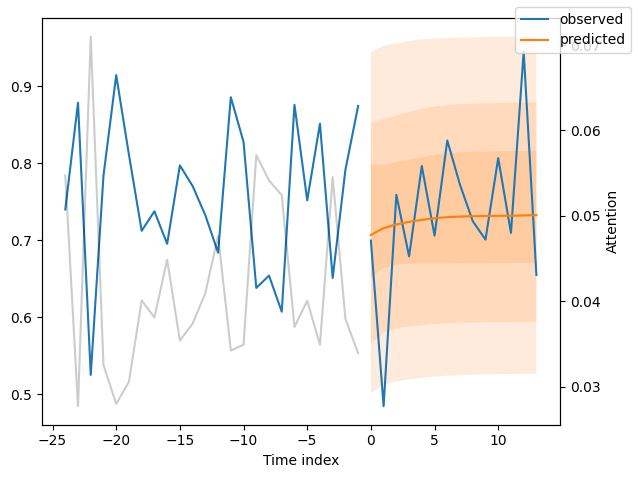

In [ ]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.metrics import QuantileLoss
from pytorch_lightning.loggers import TensorBoardLogger
from lightning.pytorch import Trainer

import lightning.pytorch as pl # Instead of import pytorch_lightning as pl
from lightning.pytorch.callbacks.early_stopping import EarlyStopping
from lightning.pytorch.callbacks import LearningRateMonitor

# Caricamento dati
df = pd.read_excel("/content/drive/Shareddrives/DU lab/Matteo Riva/WebApp/dati_combinati.xlsx")
df.columns = df.columns.str.replace('.', '_', regex=False)

df["Data"] = df.index  # Assumendo che i dati siano ordinati temporalmente
df["datetime"] = pd.to_datetime(df["Data"])
df["day_of_week"] = df["datetime"].dt.weekday
df["month"] = df["datetime"].dt.month
df["rolling_mean"] = df[target].rolling(window=7, min_periods=1).mean()
df["lag_1"] = df[target].shift(1)
df["lag_7"] = df[target].shift(7)  # Valore della settimana scorsa


days = len(df)
trend = np.linspace(0, 5, days)  # Una tendenza crescente
seasonal = 2 * np.sin(np.linspace(0, 3.14 * 2, days))  # Componente stagionale
noise = np.random.normal(0, 1, days)  # Rumore casuale

df["Evacuazioni di solo sangue"] = trend + seasonal + noise
df['No sangue'] = np.random.randint(0, 6, size=len(df))
df['Strisce di sangue'] = np.random.randint(0, 6, size=len(df))
df['Dolore addominale'] = np.random.randint(0, 6, size=len(df))
df['Urgenza'] = np.random.randint(0, 6, size=len(df))
df['Cannabis'] = np.random.randint(0, 21, size=len(df))
df['Pipa'] = np.random.randint(0, 21, size=len(df))
df['Sigaretta'] = np.random.randint(0, 21, size=len(df))
df['Sigaretta elettronica (a sublimazione)'] = np.random.randint(0, 21, size=len(df))
df['Sigaretta elettronica (a vapore)'] = np.random.randint(0, 21, size=len(df))
df['Sigaro'] = np.random.randint(0, 21, size=len(df))


target = "Evacuazioni di solo sangue"  # Nome della colonna target
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df[target] = scaler.fit_transform(df[[target]])

group_ids = ["Utente"]  # Identificatore del gruppo (es. ID cliente, serie temporale)

max_encoder_length = 24
max_prediction_length = 14  # 2 settimane (14 giorni)
batch_size = 64

training_cutoff = df["Data"].max() - max_prediction_length
training = TimeSeriesDataSet(
    df[df.Data <= training_cutoff],
    time_idx="Data",
    target=target,
    group_ids=group_ids,
    time_varying_known_reals=["Data"],
    time_varying_unknown_reals=[target],
    target_normalizer=GroupNormalizer(groups=group_ids),
    max_encoder_length=max_encoder_length,
    max_prediction_length=max_prediction_length,
)

validation = TimeSeriesDataSet.from_dataset(training, df, predict=True, stop_randomization=True)
train_dataloader = training.to_dataloader(train=True, batch_size=batch_size, num_workers=0)
val_dataloader = validation.to_dataloader(train=False, batch_size=batch_size, num_workers=0)

early_stop_callback = EarlyStopping(monitor="val_loss", min_delta=1e-4, patience=5, verbose=True, mode="min")
lr_logger = LearningRateMonitor()
logger = TensorBoardLogger("lightning_logs")

trainer = pl.Trainer(
    max_epochs=100,
    enable_model_summary=True,
    gradient_clip_val=0.1,
    callbacks=[lr_logger, early_stop_callback],
    logger=logger
)


tft = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate=0.001,
    hidden_size=200,
    attention_head_size=8,
    dropout=0.05,
    hidden_continuous_size=200,
    output_size=7,
    loss=QuantileLoss(),
    log_interval=10,
    reduce_on_plateau_patience=4
)


trainer.fit(
    tft,
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader)


best_model_path = trainer.checkpoint_callback.best_model_path
print(best_model_path)
best_tft = TemporalFusionTransformer.load_from_checkpoint(best_model_path)

# Predizione e visualizzazione
def plot_predictions(model, dataloader):
    raw_predictions = model.predict(dataloader, mode="raw", return_x=True)
    x = raw_predictions[1]  # Adjusting to correctly unpack the returned values
    raw_predictions = raw_predictions[0]
    for idx in range(1):  # Mostriamo solo una serie temporale
        plt.figure(figsize=(10, 5))
        model.plot_prediction(x, raw_predictions, idx=idx)
        plt.show()

plot_predictions(best_tft, val_dataloader)



INFO:pytorch_lightning.utilities.rank_zero:You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
/usr/local/lib/python3.11/dist-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/usr/local/lib/python3.11/dist-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.
INFO: 
   | Name                            

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/lightning/pytorch/loops/fit_loop.py:310: The number of training batches (44) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

INFO: Monitored metric val_loss did not improve in the last 5 records. Best score: 0.219. Signaling Trainer to stop.
INFO:lightning.pytorch.callbacks.early_stopping:Monitored metric val_loss did not improve in the last 5 records. Best score: 0.219. Signaling Trainer to stop.


lightning_logs/lightning_logs/version_0/checkpoints/epoch=18-step=836.ckpt


/usr/local/lib/python3.11/dist-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/usr/local/lib/python3.11/dist-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.


<Figure size 1000x500 with 0 Axes>

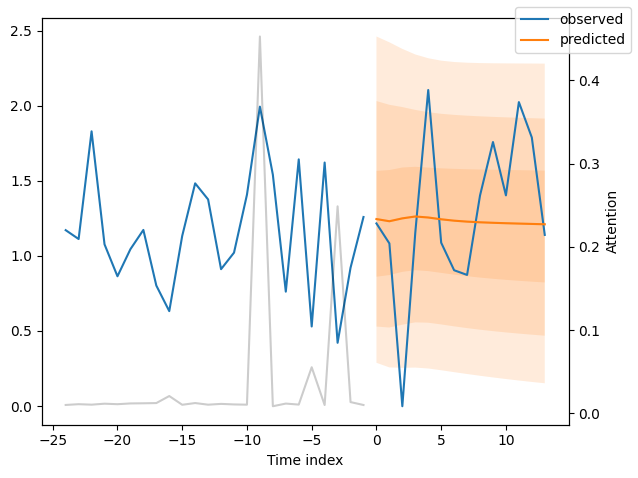

In [ ]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.metrics import QuantileLoss
from pytorch_lightning.loggers import TensorBoardLogger
from lightning.pytorch import Trainer

import lightning.pytorch as pl
from lightning.pytorch.callbacks.early_stopping import EarlyStopping
from lightning.pytorch.callbacks import LearningRateMonitor
import random

# Generazione dati sintetici migliorata
def generate_synthetic_timeseries(num_records=2922):
    start_date = pd.to_datetime("2025-04-03")
    dates = [start_date + pd.Timedelta(days=i) for i in range(num_records)]

    trend = np.linspace(0, 5, num_records)
    seasonal = 2 * np.sin(np.linspace(0, 3.14 * 4, num_records))
    noise = np.random.normal(0, 1, num_records)

    evacuazioni = trend + seasonal + noise

    cannabis = [random.randint(0, 20) for _ in range(num_records)]
    urgenza = [c + random.randint(-2, 2) if c > 10 else random.randint(0, 5) for c in cannabis]

    df = pd.DataFrame({
        "Data": dates,
        "Evacuazioni di solo sangue": evacuazioni,
        "Cannabis": cannabis,
        "Urgenza": urgenza,
    })
    return df

df = generate_synthetic_timeseries()
df["Utente"] = "User1"

# Feature Engineering
df["Data"] = pd.to_datetime(df["Data"])
df["day_of_week"] = df["Data"].dt.weekday
df["month"] = df["Data"].dt.month
df["rolling_mean"] = df["Evacuazioni di solo sangue"].rolling(window=7, min_periods=1).mean()
df["lag_1"] = df["Evacuazioni di solo sangue"].shift(1)
df["lag_7"] = df["Evacuazioni di solo sangue"].shift(7)

# Converti Data in un indice temporale intero
df["time_idx"] = (df["Data"] - df["Data"].min()).dt.days

target = "Evacuazioni di solo sangue"

# Normalizzazione dei dati
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[target] = scaler.fit_transform(df[[target]])

group_ids = ["Utente"]

max_encoder_length = 24
max_prediction_length = 14
batch_size = 64

training_cutoff = df["time_idx"].max() - max_prediction_length
training = TimeSeriesDataSet(
    df[df.time_idx <= training_cutoff],
    time_idx="time_idx",  # Usa l'indice temporale intero
    target=target,
    group_ids=group_ids,
    time_varying_known_reals=["time_idx"], # Usa l'indice temporale intero
    time_varying_unknown_reals=[target],
    target_normalizer=GroupNormalizer(groups=group_ids),
    max_encoder_length=max_encoder_length,
    max_prediction_length=max_prediction_length,
)

validation = TimeSeriesDataSet.from_dataset(training, df, predict=True, stop_randomization=True)
train_dataloader = training.to_dataloader(train=True, batch_size=batch_size, num_workers=0)
val_dataloader = validation.to_dataloader(train=False, batch_size=batch_size, num_workers=0)

early_stop_callback = EarlyStopping(monitor="val_loss", min_delta=1e-4, patience=5, verbose=True, mode="min")
lr_logger = LearningRateMonitor()
logger = TensorBoardLogger("lightning_logs")

trainer = pl.Trainer(
    max_epochs=100,
    enable_model_summary=True,
    gradient_clip_val=0.1,
    callbacks=[lr_logger, early_stop_callback],
    logger=logger
)

tft = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate=0.001,
    hidden_size=200,
    attention_head_size=8,
    dropout=0.05,
    hidden_continuous_size=200,
    output_size=7,
    loss=QuantileLoss(),
    log_interval=10,
    reduce_on_plateau_patience=4
)

trainer.fit(
    tft,
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader)

best_model_path = trainer.checkpoint_callback.best_model_path
print(best_model_path)
best_tft = TemporalFusionTransformer.load_from_checkpoint(best_model_path)

# Predizione e visualizzazione
def plot_predictions(model, dataloader):
    raw_predictions = model.predict(dataloader, mode="raw", return_x=True)
    x = raw_predictions[1]
    raw_predictions = raw_predictions[0]
    for idx in range(1):
        plt.figure(figsize=(10, 5))
        model.plot_prediction(x, raw_predictions, idx=idx)
        plt.show()

plot_predictions(best_tft, val_dataloader)

INFO:pytorch_lightning.utilities.rank_zero:You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
/usr/local/lib/python3.11/dist-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/usr/local/lib/python3.11/dist-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.
INFO: 
   | Name                            

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/lightning/pytorch/loops/fit_loop.py:310: The number of training batches (43) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

INFO: Monitored metric val_loss did not improve in the last 5 records. Best score: 0.131. Signaling Trainer to stop.
INFO:lightning.pytorch.callbacks.early_stopping:Monitored metric val_loss did not improve in the last 5 records. Best score: 0.131. Signaling Trainer to stop.


lightning_logs/lightning_logs/version_3/checkpoints/epoch=18-step=817.ckpt


/usr/local/lib/python3.11/dist-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/usr/local/lib/python3.11/dist-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.


<Figure size 1000x500 with 0 Axes>

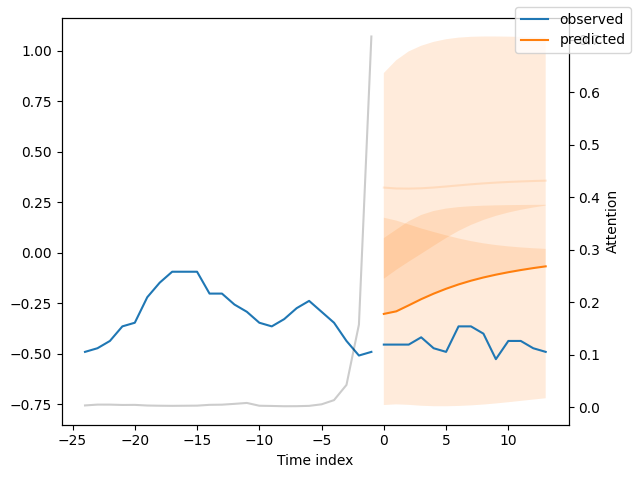

In [ ]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.metrics import QuantileLoss
from pytorch_lightning.loggers import TensorBoardLogger
from lightning.pytorch import Trainer

import lightning.pytorch as pl
from lightning.pytorch.callbacks.early_stopping import EarlyStopping
from lightning.pytorch.callbacks import LearningRateMonitor

# Caricamento e preparazione dati
df = pd.read_excel("/content/drive/Shareddrives/DU lab/Matteo Riva/WebApp/dati_luca_199.xlsx")
df = df[df['id'] == 199].copy()  # Copia per evitare Warning
df["time"] = df.index
df["time_idx"] = (df["time"] - df["time"].min())  # Indice temporale intero

# Feature Engineering
df["day_of_week"] = pd.to_datetime(df["time"]).dt.weekday
df["month"] = pd.to_datetime(df["time"]).dt.month
df["lag_1"] = df["gl"].shift(1)
df["lag_7"] = df["gl"].shift(7)

target = "gl"
group_ids = ["id"]

# Normalizzazione dei dati
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[target] = scaler.fit_transform(df[[target]])

max_encoder_length = 24
max_prediction_length = 14
batch_size = 64

training_cutoff = df["time_idx"].max() - max_prediction_length
training = TimeSeriesDataSet(
    df[df.time_idx <= training_cutoff],
    time_idx="time_idx",
    target=target,
    group_ids=group_ids,
    time_varying_known_reals=["time_idx"],
    time_varying_unknown_reals=[target],
    target_normalizer=GroupNormalizer(groups=group_ids),
    max_encoder_length=max_encoder_length,
    max_prediction_length=max_prediction_length,
)

validation = TimeSeriesDataSet.from_dataset(training, df, predict=True, stop_randomization=True)
train_dataloader = training.to_dataloader(train=True, batch_size=batch_size, num_workers=0)
val_dataloader = validation.to_dataloader(train=False, batch_size=batch_size, num_workers=0)

early_stop_callback = EarlyStopping(monitor="val_loss", min_delta=1e-4, patience=5, verbose=True, mode="min")
lr_logger = LearningRateMonitor()
logger = TensorBoardLogger("lightning_logs")

trainer = pl.Trainer(
    max_epochs=100,
    enable_model_summary=True,
    gradient_clip_val=0.1,
    callbacks=[lr_logger, early_stop_callback],
    logger=logger
)

tft = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate=0.0001,
    hidden_size=200,
    attention_head_size=8,
    dropout=0.001,
    hidden_continuous_size=200,
    output_size=7,
    loss=QuantileLoss(quantiles=[0.2, 0.5, 0.7]),  # Più stretti rispetto a [0.1, 0.5, 0.9]
    log_interval=10,
    reduce_on_plateau_patience=4
)

trainer.fit(
    tft,
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader)

best_model_path = trainer.checkpoint_callback.best_model_path
print(best_model_path)
best_tft = TemporalFusionTransformer.load_from_checkpoint(best_model_path)

# Predizione e visualizzazione
def plot_predictions(model, dataloader):
    raw_predictions = model.predict(dataloader, mode="raw", return_x=True)
    x = raw_predictions[1]
    raw_predictions = raw_predictions[0]
    for idx in range(1):
        plt.figure(figsize=(10, 5))
        model.plot_prediction(x, raw_predictions, idx=idx)
        plt.show()

plot_predictions(best_tft, val_dataloader)

In [ ]:
!pip install darts


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.0/56.0 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.7/169.7 kB 6.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 38.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.0/823.0 kB 52.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 354.4/354.4 kB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.7/101.7 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 90.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 58.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 50.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.6 MB/s eta 0:00:00

In [ ]:
!pip install -U torch pytorch-forecasting pytorch-lightning==2.0.4 pandas matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 721.2/721.2 kB 25.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.7/197.7 kB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 50.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 78.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 818.9/818.9 kB 48.4 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
  Attempting uninstall: matplotlib
    Found existing installation: matplotlib 3.10.0
    Uninstalling matplotlib-3.10.0:
      Successfully uninstalled matplotlib-3.10.0
  Attempting uninstall: pytorch-lightning
    Found existing installation: pytorch-lightning 2.5.1
    Uninstalling pytorch-lightning-2.5.1:
      Successfully uninstalled pytorch-lightning-2.5.1
ER

In [ ]:
!pip uninstall -y torch torchvision
!pip install torch torchvision

Found existing installation: torch 2.6.0+cu124
Uninstalling torch-2.6.0+cu124:
  Successfully uninstalled torch-2.6.0+cu124
Found existing installation: torchvision 0.21.0+cu124
Uninstalling torchvision-0.21.0+cu124:
  Successfully uninstalled torchvision-0.21.0+cu124
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 766.7/766.7 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 132.4 MB/s eta 0:00:00


In [ ]:
!pip install numpy==1.24.4


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.3/17.3 MB 75.3 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.2.3 which is incompatible.
jaxlib 0.5.1 requires numpy>=1.25, but you have numpy 1.24.4 which is incompatible.
tensorflow 2.18.0 requires numpy<2.1.0,>=1.26.0, but you have numpy 1.24.4 which is incompatible.
blosc2 3.3.0 requires numpy>=1.26, but you have numpy 1.24.4 which is incompatible.
jax 0.5.2 requires numpy>=1.25, but you have numpy 1.24.4 which is incompatible.
treescope 0.1.9 requires numpy>=1.25.2, but you have numpy 1.24.4 which is incompatible.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.24.4 wh

<Axes: xlabel='Month'>

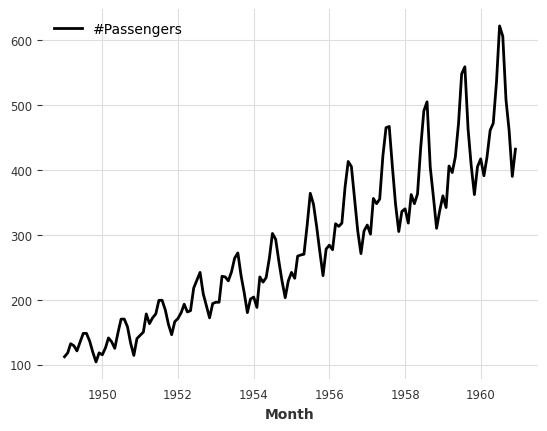

In [ ]:
series = AirPassengersDataset().load()
series.plot()

Training: 0it [00:00, ?it/s]

Predicting: 0it [00:00, ?it/s]

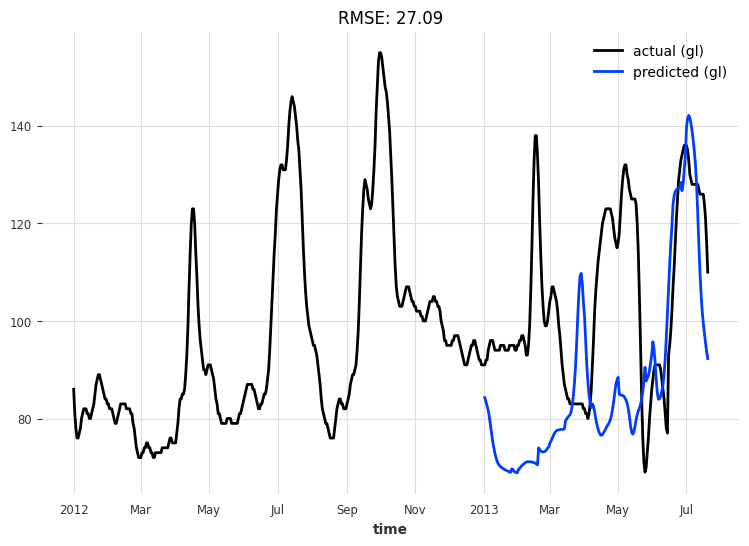

In [ ]:
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from darts import TimeSeries
from darts.dataprocessing.transformers import Scaler
from darts.metrics import rmse
from darts.metrics import mape
from darts.models import TFTModel
from darts.utils.timeseries_generation import datetime_attribute_timeseries
from torch.nn import MSELoss

warnings.filterwarnings("ignore")
import logging
logging.disable(logging.CRITICAL)

df = pd.read_excel("/content/drive/Shareddrives/DU lab/Matteo Riva/WebApp/dati_luca_1.xlsx")
df['time'] = pd.to_datetime(df['time'])

# Crea un oggetto TimeSeries
series = TimeSeries.from_dataframe(df, time_col='time', value_cols='gl')
series = series.astype(np.float32)

training_cutoff = pd.Timestamp("2013-01-01")
train, val = series.split_after(training_cutoff)

transformer = Scaler()
train_transformed = transformer.fit_transform(train)
val_transformed = transformer.transform(val)
series_transformed = transformer.transform(series)

# Crea le covariate focalizzandosi su caratteristiche mensili
covariates = datetime_attribute_timeseries(series, attribute="month", one_hot=False)

# Aggiungi le colonne aggiuntive come covariate
additional_covariates = TimeSeries.from_dataframe(df, time_col='time', value_cols=['age', 'BMI', 'glycaemia', 'HbA1c'])
covariates = covariates.stack(additional_covariates)
covariates = covariates.astype(np.float32)

# # Lag features
# for lag in [1, 2, 3, 7]:
#     df[f'gl_lag{lag}'] = df['gl'].shift(lag)
# df = df.fillna(method='ffill').fillna(method='bfill')  # Gestione dei valori nan dopo aver aggiunto le lag features
# for lag in [1, 2, 3, 7]:
#     lag_covariate = TimeSeries.from_dataframe(df, time_col='time', value_cols=[f'gl_lag{lag}'])
#     covariates = covariates.stack(lag_covariate)

scaler_covs = Scaler()
cov_train, cov_val = covariates.split_after(training_cutoff)
scaler_covs.fit(cov_train)
covariates_transformed = scaler_covs.transform(covariates)

# Assicurati che tutte le covariate siano di tipo float32
covariates_transformed = covariates_transformed.astype(np.float32)

input_chunk_length = 36  # Aumentato per includere più dati storici (36)
forecast_horizon = 24  # Aumentato per previsioni a lungo termine (24)

my_model = TFTModel(
    input_chunk_length=input_chunk_length,
    output_chunk_length=forecast_horizon,
    hidden_size=128, # a 128 è 17%, a 256 è a 35%
    lstm_layers=1, # lasciare a 1
    num_attention_heads=8, # a 16 intorno al 23%, a 8 intorno al 19 %, a 4 è 20%
    dropout=0.1,
    batch_size=32, #a 32 è a 17%, a 16 è a 33%, a 64 è 40%
    n_epochs=400, # a 400 è 17%
    add_relative_index=True,
    add_encoders=None,
    likelihood=None,
    loss_fn=MSELoss(),
    random_state=42,
)

my_model.fit(train_transformed, future_covariates=covariates_transformed, verbose=True)

figsize = (9, 6)
num_samples = 1

def eval_model(model, n, actual_series, val_series):
    pred_series = model.predict(n=n, num_samples=num_samples)

    pred_series_orig = transformer.inverse_transform(pred_series)
    actual_series_orig = transformer.inverse_transform(actual_series[: pred_series.end_time()])

    plt.figure(figsize=figsize)
    actual_series_orig.plot(label="actual (gl)")
    pred_series_orig.plot(label="predicted (gl)")

    error = rmse(
        transformer.inverse_transform(val_series),
        pred_series_orig
    )

    plt.title(f"RMSE: {error:.2f}")
    plt.legend()
    plt.show()


eval_model(my_model, len(val), series_transformed, val_transformed)


Predicting: 0it [00:00, ?it/s]

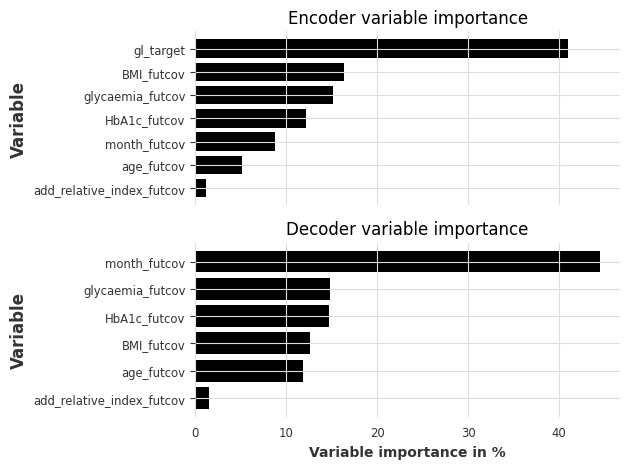

In [ ]:
from darts.explainability import TFTExplainer
explainer = TFTExplainer(my_model)
explainability_result = explainer.explain()
explainer.plot_variable_selection(explainability_result)


<Axes: xlabel='time'>

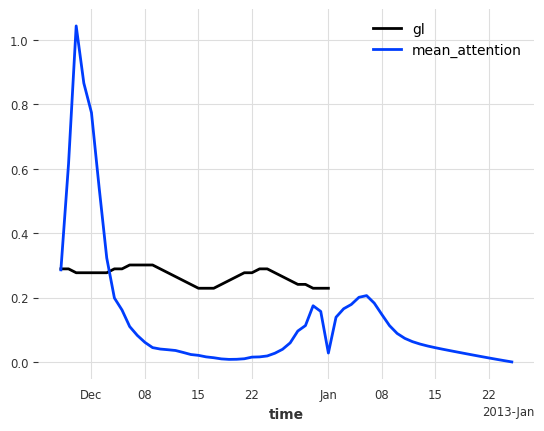

In [ ]:
attention = explainability_result.get_attention().mean(axis=1)

time_intersection = train_transformed.time_index.intersection(attention.time_index)

train_transformed[time_intersection].plot()
attention.plot(label="mean_attention", max_nr_components=12)

Training: 0it [00:00, ?it/s]

Predicting: 0it [00:00, ?it/s]

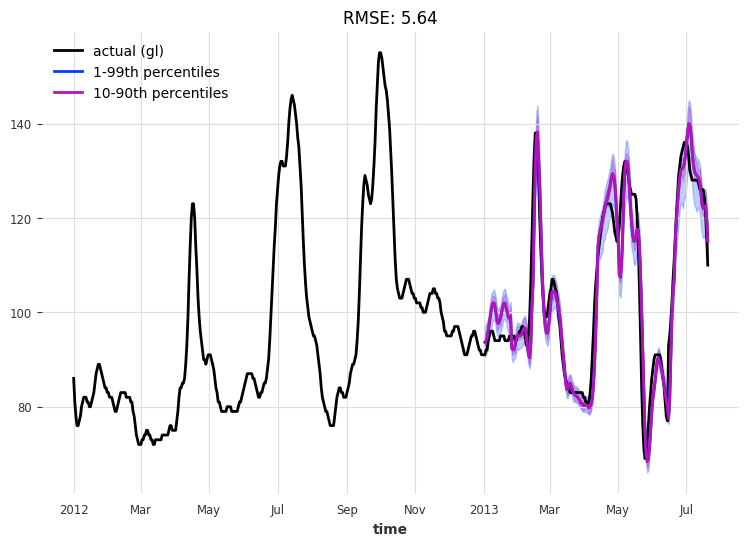

In [ ]:
# probabilistico

import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from darts import TimeSeries
from darts.dataprocessing.transformers import Scaler
from darts.metrics import rmse
from darts.metrics import mape
from darts.models import TFTModel
from darts.utils.timeseries_generation import datetime_attribute_timeseries
from torch.nn import MSELoss
from darts.utils.likelihood_models import QuantileRegression

warnings.filterwarnings("ignore")
import logging
logging.disable(logging.CRITICAL)

# before starting, we define some constants
num_samples = 200

figsize = (9, 6)
lowest_q, low_q, high_q, highest_q = 0.01, 0.1, 0.9, 0.99
label_q_outer = f"{int(lowest_q * 100)}-{int(highest_q * 100)}th percentiles"
label_q_inner = f"{int(low_q * 100)}-{int(high_q * 100)}th percentiles"

df = pd.read_excel("/content/drive/Shareddrives/DU lab/Matteo Riva/WebApp/dati_luca_1.xlsx")
df['time'] = pd.to_datetime(df['time'])

series = TimeSeries.from_dataframe(df, time_col='time', value_cols='gl')
series = series.astype(np.float32)

training_cutoff = pd.Timestamp("2013-01-01")
train, val = series.split_after(training_cutoff)

transformer = Scaler()
train_transformed = transformer.fit_transform(train)
val_transformed = transformer.transform(val)
series_transformed = transformer.transform(series)

# Crea le covariate focalizzandosi su caratteristiche mensili
covariates = datetime_attribute_timeseries(series, attribute="month", one_hot=False)

# Aggiungi le colonne aggiuntive come covariate
additional_covariates = TimeSeries.from_dataframe(df, time_col='time', value_cols=['age', 'BMI', 'glycaemia', 'HbA1c'])
covariates = covariates.stack(additional_covariates)
covariates = covariates.astype(np.float32)

# Lag features
for lag in range(1, 4):  # Aggiungi lag di 1, 2 e 3 mesi
    df[f'gl_lag{lag}'] = df['gl'].shift(lag)
df = df.fillna(method='ffill').fillna(method='bfill')  # Gestione dei valori nan dopo aver aggiunto le lag features
for lag in range(1, 4):
    lag_covariate = TimeSeries.from_dataframe(df, time_col='time', value_cols=[f'gl_lag{lag}'])
    covariates = covariates.stack(lag_covariate)

scaler_covs = Scaler()
cov_train, cov_val = covariates.split_after(training_cutoff)
scaler_covs.fit(cov_train)
covariates_transformed = scaler_covs.transform(covariates)

# Assicurati che tutte le covariate siano di tipo float32
covariates_transformed = covariates_transformed.astype(np.float32)

input_chunk_length = 36  # Aumentato per includere più dati storici
forecast_horizon = 24  # Aumentato per previsioni a lungo termine

# default quantiles for QuantileRegression
quantiles = [
    0.01,
    0.05,
    0.1,
    0.15,
    0.2,
    0.25,
    0.3,
    0.4,
    0.5,
    0.6,
    0.7,
    0.75,
    0.8,
    0.85,
    0.9,
    0.95,
    0.99,
]

my_model = TFTModel(
    input_chunk_length=input_chunk_length,
    output_chunk_length=forecast_horizon,
    hidden_size=128, # a 128 è 17%, a 256 è a 35%
    lstm_layers=1, # lasciare a 1
    num_attention_heads=8, # a 16 intorno al 23%, a 8 intorno al 19 %, a 4 è 20%
    dropout=0.1,
    batch_size=32, #a 32 è a 17%, a 16 è a 33%, a 64 è 40%
    n_epochs=400, # a 400 è 17%
    add_relative_index=True,
    add_encoders=None,
    likelihood=QuantileRegression(quantiles=quantiles),
    random_state=42,
)

my_model.fit(train_transformed, future_covariates=covariates_transformed, verbose=True)

def eval_model(model, n, actual_series, val_series):
    pred_series = model.predict(n=n, num_samples=num_samples)

    pred_series_orig = transformer.inverse_transform(pred_series)
    actual_series_orig = transformer.inverse_transform(actual_series[: pred_series.end_time()])
    val_series_orig = transformer.inverse_transform(val_series)

    plt.figure(figsize=figsize)
    actual_series_orig.plot(label="actual (gl)")

    pred_series_orig.plot(
        low_quantile=lowest_q, high_quantile=highest_q, label=label_q_outer
    )
    pred_series_orig.plot(
        low_quantile=low_q, high_quantile=high_q, label=label_q_inner
    )

    error = rmse(val_series_orig, pred_series_orig)

    plt.title(f"RMSE: {error:.2f}")
    plt.legend()
    plt.show()


eval_model(my_model, len(val), series_transformed, val_transformed)


Predicting: 0it [00:00, ?it/s]

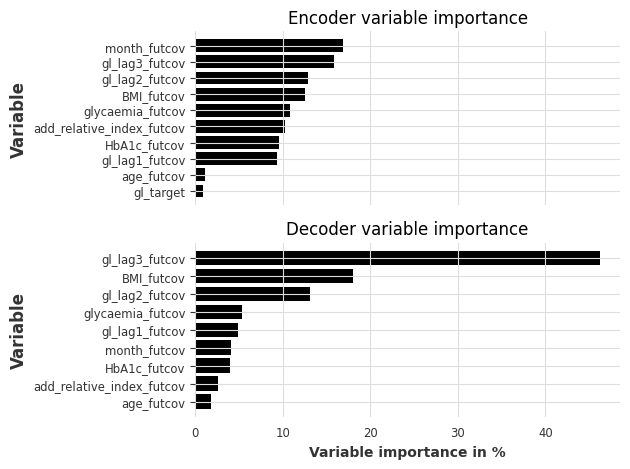

In [ ]:
from darts.explainability import TFTExplainer
explainer = TFTExplainer(my_model)
explainability_result = explainer.explain()
explainer.plot_variable_selection(explainability_result)


<Axes: xlabel='time'>

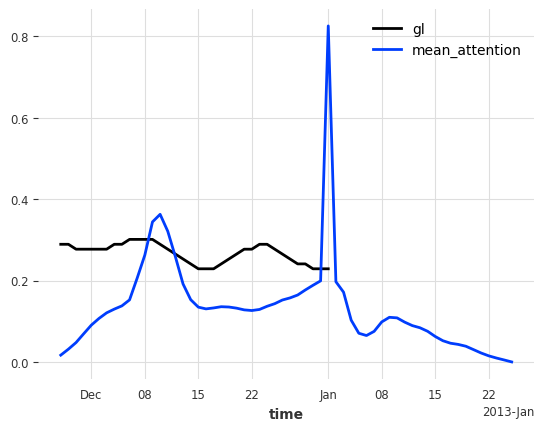

In [ ]:
attention = explainability_result.get_attention().mean(axis=1)

time_intersection = train_transformed.time_index.intersection(attention.time_index)

train_transformed[time_intersection].plot()
attention.plot(label="mean_attention", max_nr_components=12)